# Basic Neural Network

Một notebook, sáu bước. Toàn bộ code viết trực tiếp trong từng cell:
dữ liệu → Sequential → compile → fit → evaluate. Chỉ phát triển mạng Dense.

Thử BatchNormalization, hai lớp Dense và Dropout nhẹ hơn để cải thiện baseline.
Chọn checkpoint bằng validation loss. Baseline cũ 59,75% được giữ trong
`results/basic_nn/`; bản mới lưu ở `results/basic_nn_notebook/`.
`TRAIN_MODEL=True` để train; False để đánh giá checkpoint đã lưu.


## 1. Import và cấu hình

In [1]:
from pathlib import Path
import json
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

ROOT = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
CLASS_NAMES = ['fire', 'nofire', 'smoke', 'smokefire']
SEED = 42

IMAGE_SIZE = (64, 64)
PATH_COLUMN = 'processed_filepath'
TRAIN_MODEL = True
RESULT_DIR = ROOT / 'results/basic_nn_notebook'
MODEL_PATH = ROOT / 'models/basic_nn_notebook.keras'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(exist_ok=True)
training_config = dict(dense_units=[256, 128], dropout=[0.3, 0.2],
                       learning_rate=3e-4, batch_size=32, epochs=30)
if not TRAIN_MODEL:
    saved = json.loads((RESULT_DIR / 'metrics.json').read_text(encoding='utf-8'))
    training_config = saved['training_config']
    IMAGE_SIZE = tuple(saved['image_size'])
    PATH_COLUMN = saved['source']
    SEED = saved['seed']
    assert saved['class_names'] == CLASS_NAMES, 'Mapping checkpoint không khớp.'
tf.keras.utils.set_random_seed(SEED)


## 2. Dữ liệu, preprocessing và augmentation

Chạy notebook 00 nếu chưa có manifest/ảnh processed. Ảnh RGB 64×64,
pixel [0, 1]. Antialias giảm răng cưa khi thu nhỏ ảnh. Train được shuffle;
lật ngang nằm trong model và chỉ hoạt động lúc train. Validation/test giữ thứ tự.


In [2]:
frame = pd.read_csv(ROOT / 'data/split.csv')
frame = frame[frame['status'] == 'ok'].copy()
assert frame['label'].map(dict(zip(CLASS_NAMES, range(4)))).equals(frame['class_index'])
assert set(frame['split']) == {'train', 'val', 'test'}
train, val, test = [frame[frame['split'] == split].reset_index(drop=True)
                    for split in ['train', 'val', 'test']]
assert all(len(part) > 0 for part in [train, val, test])
display(pd.crosstab(frame['split'], frame['label'])[CLASS_NAMES])

# Một hàm đọc ảnh dùng chung cho ba tập, ảnh luôn đi cùng nhãn.
def read_image(path, label):
    image = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = image / 255.0
    return image, label

datasets = []
for part in [train, val, test]:
    paths = [str((ROOT / path).resolve()) for path in part[PATH_COLUMN]]
    assert all(Path(path).is_file() for path in paths), 'Thiếu ảnh, chạy notebook 00 trước.'
    ds = tf.data.Dataset.from_tensor_slices((paths, part['class_index'].to_numpy()))
    ds = ds.map(read_image, num_parallel_calls=tf.data.AUTOTUNE)
    datasets.append(ds)
train_ds, val_ds, test_ds = datasets
train_ds = train_ds.shuffle(len(train), seed=SEED).batch(training_config['batch_size']).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(training_config['batch_size']).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(training_config['batch_size']).prefetch(tf.data.AUTOTUNE)

label,fire,nofire,smoke,smokefire
split,,,,
test,200,200,200,200
train,800,800,800,800
val,200,200,200,200


## 3. Xây model và compile

Flatten → Dense(256) → BatchNormalization → ReLU → Dropout(0,3)
→ Dense(128, ReLU) → Dropout(0,2) → Dense(4, Softmax).
BatchNormalization giúp ổn định đầu vào của ReLU; Dropout hạn chế overfitting.
Nhãn số nguyên dùng sparse cross-entropy, không cần thêm bước one-hot.

Chỉ xây và compile khi train. Khi đánh giá, load trực tiếp checkpoint hiện tại.


In [3]:
if TRAIN_MODEL:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(*IMAGE_SIZE, 3)),
        tf.keras.layers.RandomFlip('horizontal', seed=SEED),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(training_config['dense_units'][0], use_bias=False, kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(training_config['dropout'][0]),
        tf.keras.layers.Dense(training_config['dense_units'][1], activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.Dropout(training_config['dropout'][1]),
        tf.keras.layers.Dense(4, activation='softmax'),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(training_config['learning_rate']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
else:
    model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,180,164 (12.13 MB)

 Trainable params: 3,179,652 (12.13 MB)

 Non-trainable params: 512 (2.00 KB)

## 4. Train và chọn checkpoint

Tối đa số epoch trong cấu hình. Chọn checkpoint bằng validation loss, giảm
learning rate khi loss đứng yên. Test chỉ dùng báo cáo cuối.
`TRAIN_MODEL=False` đọc checkpoint, history và cấu hình đã lưu của bản hiện tại.
Nếu chưa có các tệp đó, chạy với `TRAIN_MODEL=True` trước.


Epoch 1/30


100/100 - 3s - 27ms/step - accuracy: 0.5672 - loss: 1.0245 - val_accuracy: 0.6313 - val_loss: 0.9034 - learning_rate: 3.0000e-04


Epoch 2/30


100/100 - 2s - 18ms/step - accuracy: 0.6316 - loss: 0.8824 - val_accuracy: 0.6862 - val_loss: 0.7947 - learning_rate: 3.0000e-04


Epoch 3/30


...

Epoch 22/30


100/100 - 2s - 17ms/step - accuracy: 0.7722 - loss: 0.5646 - val_accuracy: 0.7487 - val_loss: 0.6482 - learning_rate: 1.8750e-05


Epoch 23/30


100/100 - 2s - 17ms/step - accuracy: 0.7766 - loss: 0.5560 - val_accuracy: 0.7450 - val_loss: 0.6409 - learning_rate: 1.0000e-05


Epoch có val_loss thấp nhất: 18


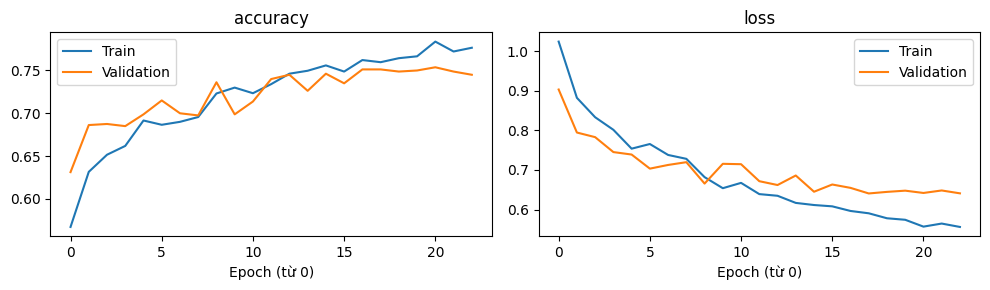

In [4]:
if TRAIN_MODEL:
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5),
    ]
    history = pd.DataFrame(model.fit(train_ds, validation_data=val_ds,
        epochs=training_config['epochs'], callbacks=callbacks, shuffle=False, verbose=2).history)
    history.to_csv(RESULT_DIR / 'training_history.csv', index=False)
    model = tf.keras.models.load_model(MODEL_PATH)
else:
    history = pd.read_csv(RESULT_DIR / 'training_history.csv')
assert tuple(model.input_shape[1:3]) == IMAGE_SIZE
print('Epoch có val_loss thấp nhất:', int(history['val_loss'].argmin()) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history[metric], label='Train')
    ax.plot(history['val_' + metric], label='Validation')
    ax.set(xlabel='Epoch (từ 0)', title=metric)
    ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'accuracy_loss_curves.png', dpi=150)
plt.show()

## 5. Đánh giá và xem kết quả

Accuracy, Precision/Recall/F1, confusion matrix và ảnh sai được tính trực tiếp.
Hàng = nhãn thật, cột = dự đoán. Lưu kết quả riêng, không ghi đè báo cáo cũ.

,precision,recall,f1-score,support
fire,0.7799,0.6200,0.6908,200.0000
nofire,0.6422,0.7450,0.6898,200.0000
smoke,0.5543,0.7400,0.6338,200.0000
smokefire,0.4296,0.3050,0.3567,200.0000
accuracy,0.6025,0.6025,0.6025,0.6025
macro avg,0.6015,0.6025,0.5928,800.0000
weighted avg,0.6015,0.6025,0.5928,800.0000


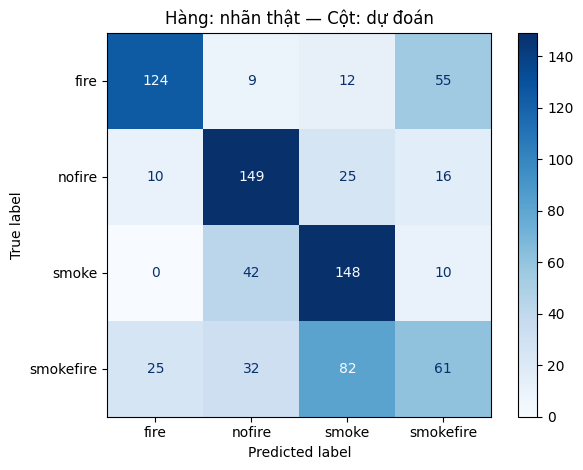

Accuracy: 60.25% | Macro F1: 0.5928
smokefire → smoke: 82 | smoke → smokefire: 10


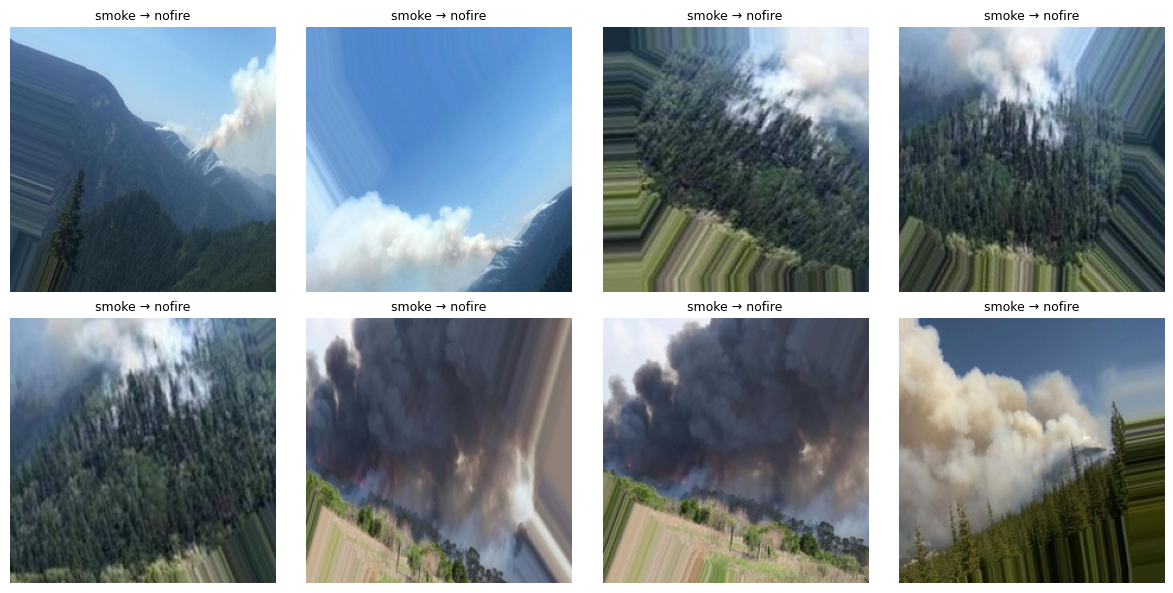

In [5]:
loss, accuracy = model.evaluate(test_ds, verbose=0)
probabilities = model.predict(test_ds, verbose=0)
y_true = test['class_index'].to_numpy()
y_pred = probabilities.argmax(axis=1)
assert np.isclose(accuracy, (y_true == y_pred).mean())
report = classification_report(y_true, y_pred, labels=range(4),
    target_names=CLASS_NAMES, output_dict=True, zero_division=0)
matrix = confusion_matrix(y_true, y_pred, labels=range(4))
display(pd.DataFrame(report).T.round(4))
ConfusionMatrixDisplay(matrix, display_labels=CLASS_NAMES).plot(cmap='Blues')
plt.title('Hàng: nhãn thật — Cột: dự đoán')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

predictions = test[['filepath', 'processed_filepath', 'label', 'class_index']].copy()
predictions['predicted_label'] = np.array(CLASS_NAMES)[y_pred]
predictions['confidence'] = probabilities.max(axis=1)
mistakes = predictions[y_true != y_pred]
mistakes.to_csv(RESULT_DIR / 'misclassified.csv', index=False)
predictions.to_csv(RESULT_DIR / 'predictions.csv', index=False)
pd.DataFrame(report).T.to_csv(RESULT_DIR / 'classification_report.csv', index_label='class')
pd.DataFrame(matrix, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    RESULT_DIR / 'confusion_matrix.csv', index_label='true_label')
metrics = {'test_accuracy': float(accuracy), 'test_loss': float(loss),
           'macro_f1': report['macro avg']['f1-score'],
           'misclassified_count': len(mistakes), 'parameter_count': model.count_params(),
           'class_names': CLASS_NAMES, 'image_size': list(IMAGE_SIZE),
           'source': PATH_COLUMN, 'seed': SEED, 'test_images': len(test),
           'best_val_loss': float(history['val_loss'].min()),
           'best_val_accuracy': float(history.loc[history['val_loss'].idxmin(), 'val_accuracy']),
           'tensorflow_version': tf.__version__,
           'training_config': training_config}
(RESULT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
print(f'Accuracy: {accuracy:.2%} | Macro F1: {metrics["macro_f1"]:.4f}')
print('smokefire → smoke:', matrix[3, 2], '| smoke → smokefire:', matrix[2, 3])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
examples = mistakes[mistakes['label'].isin(['smoke', 'smokefire'])].head(8)
for ax in axes.flat:
    ax.axis('off')
for ax, row in zip(axes.flat, examples.itertuples()):
    with Image.open(ROOT / getattr(row, PATH_COLUMN)) as image:
        ax.imshow(ImageOps.exif_transpose(image).convert('RGB'))
    ax.set_title(f'{row.label} → {row.predicted_label}', fontsize=9)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'misclassified_samples.png', dpi=150)
plt.show()

## 6. Báo cáo và tệp đầu ra

So sánh bản Dense mới với baseline. Accuracy tăng không đồng nghĩa đã sửa được
nhãn mơ hồ hoặc ảnh raw bị kéo sọc. Không đảo nhãn smoke/smokefire theo prediction.
Ảnh 64×64 vẫn có thể mất chi tiết nhỏ; cần đọc cả confusion matrix và F1.


In [6]:
baseline = json.loads((ROOT / 'results/basic_nn/metrics.json').read_text(encoding='utf-8'))
display(pd.DataFrame([
    {'model': 'Basic NN cũ', 'accuracy': baseline['test_accuracy'], 'macro_f1': baseline['macro_f1']},
    {'model': 'Basic NN hiện tại', 'accuracy': metrics['test_accuracy'], 'macro_f1': metrics['macro_f1']},
]))
print(f"Chênh lệch accuracy: {(metrics['test_accuracy'] - baseline['test_accuracy']) * 100:+.2f} điểm phần trăm")
print('Kết quả:', RESULT_DIR)
if TRAIN_MODEL:
    MODEL_PATH.with_suffix('.labels.json').write_text(json.dumps(CLASS_NAMES), encoding='utf-8')

,model,accuracy,macro_f1
0,Basic NN cũ,0.5975,0.600574
1,Basic NN hiện tại,0.6025,0.592795


Chênh lệch accuracy: +0.50 điểm phần trăm
Kết quả: C:\Users\admin\OneDrive - National Economics University\Documents\TÀI LIỆU\GIÁO TRÌNH HỌC\DEEP NEURAL NETWORK\Fire-and-smoke-detection-using-D-Fire\results\basic_nn_notebook
